# Simple Models — Building Up to the Final Ensemble

**Bridge from `data_analysis.ipynb`.** That notebook characterized normal: train and val are interchangeable; test differs from them along several axes (single date 2012-06-21, 70% INTC+MSFT, mass-spike rows, fat-tailed joint structure). The data analysis ended with a feature-engineering plan that pointed to per-row ratio features, per-symbol normalization, and windowed temporal features. **This notebook starts implementing that plan progressively.**

**Goal**: build a sequence of progressively richer models, finishing with an ensemble that mirrors the architecture of the final v2 model. Each model adds something the previous one couldn't capture:

1. **Data cleaning** — apply the cleanup decisions from the EDA (drop `ClusterNo`, harmonize `index`/`ID`, parse `OriginalSequenceNumber`, fill NaNs).
2. **Feature engineering** — build the 37-feature set used by `v2_dense_autoencoder.ipynb`: 14 raw columns, 14 per-symbol z-scores, 2 z-score aggregates, 4 abs-/spread-based features, 3 burst features.
3. **Synthetic anomaly labels** — train+val are 100% normal, so to train any *supervised* model we inject synthetic anomalies (multiply returns by a large factor) into a sample of train. This is the same technique used by the `validate_auroc.py` block at the end of v2.
4. **Logistic Regression** — linear baseline. Establishes whether linear separation in z-score / burst space is even possible.
5. **Random Forest** — non-linear, captures interactions (e.g. `burst_10_49` × `max_zscore`) the linear model misses.
6. **SVM (linear)** — different inductive bias from RF, useful as ensemble component.
7. **Autoencoder** — unsupervised. Trains only on normal; high reconstruction error on test = anomaly. This is the v2 architecture exactly.
8. **Ensemble (RF + SVM + AE)** — combines the three, mirroring v2's IF + AE + z-score ensemble.
9. **Synthetic-AUROC validation** — since test labels are hidden, we estimate AUROC by injecting fresh synthetic anomalies into val and scoring each model.

**No data leakage**: all stats and scalers are fit on (train+val) normal data only. Test is only ever scored, never used for fitting or thresholding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 90

NUMERIC_FEATURES = [
    'ReturnBid1', 'ReturnAsk1',
    'DerivativeReturnBid1', 'DerivativeReturnAsk1',
    'BidSize1', 'AskSize1',
    'TradeBidSize', 'TradeAskSize',
    'CancelledBidSize', 'CancelledAskSize',
    'TradeBidIndicator', 'TradeAskIndicator',
    'CancelledBidIndicator', 'CancelledAskIndicator',
]

print('Imports done.')

Imports done.


## 1. Data Cleaning

The EDA in `data_analysis.ipynb` identified four cleanup actions that should be applied before any modelling:

| Issue (from EDA) | Action |
|---|---|
| `ClusterNo` is 100% NaN in train and val and absent from test | Drop the column |
| `index` (test) vs `ID` (train/val) — same role, different name | Rename `index` → `ID` |
| `OriginalSequenceNumber` is `int64` in train/val but `object` (e.g. `'16120456-000001-000'`) in test | Extract a uniform `base_seq` column from the prefix |
| Test has 36 NaNs in size columns + 1 NaN in returns | Fill numeric features with `0` (the post-standardization mode for "no event") |

We also build the normal pool (`train + val`) here, since both are 100% normal and v2 uses them jointly for fitting.

In [2]:
print('Loading data...')
train = pd.read_csv('train_data.csv')
val   = pd.read_csv('val_data.csv')
test  = pd.read_csv('test_data.csv')
print(f'  raw shapes - train: {train.shape}, val: {val.shape}, test: {test.shape}')

# 1) Drop ClusterNo (100% NaN in train/val; absent from test)
for df in (train, val):
    if 'ClusterNo' in df.columns:
        df.drop(columns=['ClusterNo'], inplace=True)

# 2) Harmonize the row identifier: test uses 'index', train/val use 'ID'
if 'index' in test.columns and 'ID' not in test.columns:
    test = test.rename(columns={'index': 'ID'})

# 3) Build a uniform base_seq column. In test, OriginalSequenceNumber is a string like
#    '16120456-000001-000'; we split on '-' and take the prefix. In train/val the column
#    is already an int; we cast to str for dtype consistency.
test ['base_seq'] = test ['OriginalSequenceNumber'].astype(str).str.split('-').str[0]
train['base_seq'] = train['OriginalSequenceNumber'].astype(str)
val  ['base_seq'] = val  ['OriginalSequenceNumber'].astype(str)

# 4) Fill numeric NaNs with 0 (post-standardization "no event" mode value).
for df in (train, val, test):
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)

# 5) Build the normal pool used for fitting all stats / unsupervised models.
normal = pd.concat([train, val], ignore_index=True)

print(f'\nAfter cleaning:')
print(f'  train  : {train.shape}')
print(f'  val    : {val.shape}')
print(f'  normal : {normal.shape}  (train+val pool, used for ALL fitting)')
print(f'  test   : {test.shape}')
print(f'\nRemaining nulls in feature columns (should all be 0):')
for label, df in [('train', train), ('val', val), ('test', test)]:
    print(f'  {label}: {df[NUMERIC_FEATURES].isnull().sum().sum()}')

Loading data...


  raw shapes - train: (1070022, 23), val: (467939, 23), test: (289101, 21)



After cleaning:
  train  : (1070022, 23)
  val    : (467939, 23)
  normal : (1537961, 23)  (train+val pool, used for ALL fitting)
  test   : (289101, 22)

Remaining nulls in feature columns (should all be 0):
  train: 0
  val: 0
  test: 0


## 2. Feature Engineering

We replicate the **37-feature set** used by `v2_dense_autoencoder.ipynb` so this notebook plugs straight into that model later. Three families of features:

| Family | Count | Purpose |
|---|---:|---|
| **Raw numeric features** | 14 | The original LOB columns (returns, sizes, indicators) |
| **Per-symbol z-scores** | 14 + 2 | `\|x − μ_sym\| / σ_sym` per feature, plus `max_zscore` and `mean_zscore` aggregates. Per-symbol because Section 3 of the EDA showed `BidSize1` has 3.15× per-symbol scale variation. |
| **Magnitude / spread features** | 4 | `max_abs_feat`, `abs_RetBid1`, `abs_RetAsk1`, `return_spread = \|RetBid1 − RetAsk1\|`. Spread divergence is a stress / manipulation cue (Section 5 finding). |
| **Burst features** | 3 | `burst_size = #rows sharing a base_seq`, `burst_log = log1p(burst_size)`, `burst_10_49`, `burst_50plus`. Test rows with shared `base_seq` come from the `'-000001-000'` sub-event encoding; v2's notebook found this is the strongest per-row anomaly signal. |

All stats (`μ_sym`, `σ_sym`) are fit on the **normal pool** (train + val) only. **No test statistics are ever used.**

In [3]:
def compute_training_stats(normal_df):
    """Per-symbol mean and std on numeric features. Fit on NORMAL DATA ONLY."""
    filled = normal_df[NUMERIC_FEATURES].fillna(0)
    stats = {}
    for sym in normal_df['ExternalSymbol'].unique():
        mask = (normal_df['ExternalSymbol'] == sym).values
        sub  = filled.values[mask]
        stats[sym] = {
            col: (sub[:, j].mean(), max(sub[:, j].std(), 1e-9))
            for j, col in enumerate(NUMERIC_FEATURES)
        }
    stats['__global__'] = {
        col: (filled[col].mean(), max(filled[col].std(), 1e-9))
        for col in NUMERIC_FEATURES
    }
    return stats


def compute_zscores(df, stats):
    """|z| per feature using per-symbol mean/std from the normal pool."""
    filled  = df[NUMERIC_FEATURES].fillna(0).values
    zscores = np.zeros_like(filled)
    for sym in df['ExternalSymbol'].unique():
        mask      = (df['ExternalSymbol'] == sym).values
        sym_stats = stats.get(sym, stats['__global__'])
        for j, col in enumerate(NUMERIC_FEATURES):
            mu, sig          = sym_stats[col]
            zscores[mask, j] = np.abs((filled[mask, j] - mu) / sig)
    return zscores


def add_burst_features(df):
    """Count rows that share the same base_seq, then derive log + threshold flags."""
    df = df.copy()
    burst             = df.groupby('base_seq').size().rename('burst_size')
    df                = df.join(burst, on='base_seq')
    df['burst_log']    = np.log1p(df['burst_size'])
    df['burst_10_49']  = ((df['burst_size'] >= 10) & (df['burst_size'] < 50)).astype(float)
    df['burst_50plus'] = (df['burst_size'] >= 50).astype(float)
    return df


def engineer_features(df, stats):
    """Build the full 37-column feature matrix.

    Returns:
        df_with_extras: DataFrame with all engineered cols added
        X:              numpy array of the 37 model-input features
    """
    df = df.copy()
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)
    zscores = compute_zscores(df, stats)
    df['max_zscore']  = zscores.max(axis=1)
    df['mean_zscore'] = zscores.mean(axis=1)
    for j, col in enumerate(NUMERIC_FEATURES):
        df[f'z_{col}'] = zscores[:, j]
    df['max_abs_feat']  = df[NUMERIC_FEATURES].abs().max(axis=1)
    df['abs_RetBid1']   = df['ReturnBid1'].abs()
    df['abs_RetAsk1']   = df['ReturnAsk1'].abs()
    df['return_spread'] = (df['ReturnBid1'] - df['ReturnAsk1']).abs()
    feat_cols = (
        NUMERIC_FEATURES
        + ['max_zscore', 'mean_zscore']
        + [f'z_{c}' for c in NUMERIC_FEATURES]
        + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']
        + ['burst_log', 'burst_10_49', 'burst_50plus']
    )
    return df, df[feat_cols].fillna(0).values


print('Helper functions defined.')

Helper functions defined.


In [4]:
print('Adding burst features...')
train  = add_burst_features(train)
val    = add_burst_features(val)
test   = add_burst_features(test)
normal = add_burst_features(normal)

print('Computing per-symbol stats on the normal pool...')
stats = compute_training_stats(normal)
print(f'  symbols seen: {[s for s in stats if s != "__global__"]}')

print('Building feature matrices...')
normal_feat, X_normal = engineer_features(normal, stats)
val_feat,    X_val    = engineer_features(val,    stats)
test_feat,   X_test   = engineer_features(test,   stats)

print(f'\nFeature matrix shapes (37 cols each):')
print(f'  X_normal : {X_normal.shape}  -- used to FIT models')
print(f'  X_val    : {X_val.shape}     -- held out for synthetic-AUROC validation')
print(f'  X_test   : {X_test.shape}    -- scored, never fit on')

Adding burst features...


Computing per-symbol stats on the normal pool...


  symbols seen: ['INTC', 'AAPL', 'GOOG', 'MSFT', 'AMZN']
Building feature matrices...



Feature matrix shapes (37 cols each):
  X_normal : (1537961, 37)  -- used to FIT models
  X_val    : (467939, 37)     -- held out for synthetic-AUROC validation
  X_test   : (289101, 37)    -- scored, never fit on


## 3. Synthetic Anomaly Labels for Supervised Models

The labels available to us are degenerate: train and val are 100% normal, test labels are hidden. To train any *supervised* classifier (LR / RF / SVM) we need a **labeled binary dataset**. The standard solution in semi-supervised anomaly detection is **synthetic anomaly injection**: take normal rows and perturb them in a way that mimics what real anomalies do, label those as fraud, and train a classifier to distinguish them from normal.

This is the same idea used by `validate_auroc.py` at the end of `v2_dense_autoencoder.ipynb` (multiplying `ReturnBid1` and `ReturnAsk1` by ×10–50). We adopt the same recipe.

**Recipe**:

1. Sample `N_normal = 100,000` rows from train as the negative class (label = 0). We sample to keep training fast for SVM.
2. Sample `N_synth = 20,000` rows, also from train, perturb their return-related columns by a random factor in `[10, 50]`, and label them as fraud (label = 1). Re-engineer the features for the perturbed rows so `max_zscore`, `abs_RetBid1`, etc. reflect the perturbation.
3. Combine into a `120,000 × 37` matrix with binary labels for LR / RF / SVM.

**Caveat**: the synthetic anomalies only mimic *return-magnitude* manipulation patterns (most relevant to pump-and-dump). Layering and quote-stuffing fingerprints aren't injected this way, so the supervised models trained on synthetic labels will be biased toward catching return-magnitude anomalies. The autoencoder (Section 7) doesn't have this bias because it doesn't use the synthetic labels at all.

In [5]:
def inject_synthetic_anomalies(df, n_synth, seed):
    """Take n_synth random rows of df, multiply return-related columns by a
    random factor in [10, 50]. Return the perturbed slice (same shape, labels = 1)."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), n_synth, replace=False)
    s   = df.iloc[idx].copy().reset_index(drop=True)
    scale_bid = rng.uniform(10, 50, n_synth)
    scale_ask = scale_bid * rng.uniform(0.8, 1.2, n_synth)
    s['ReturnBid1']           = s['ReturnBid1'] * scale_bid
    s['ReturnAsk1']           = s['ReturnAsk1'] * scale_ask
    s['DerivativeReturnBid1'] = s['DerivativeReturnBid1'] * scale_bid
    s['DerivativeReturnAsk1'] = s['DerivativeReturnAsk1'] * scale_ask
    return s


N_NORMAL = 100_000
N_SYNTH  =  20_000

print(f'Sampling {N_NORMAL:,} normal rows from train and {N_SYNTH:,} rows for synthetic anomaly injection...')
rng = np.random.default_rng(42)
normal_idx = rng.choice(len(train), N_NORMAL, replace=False)
labeled_normal = train.iloc[normal_idx].copy().reset_index(drop=True)
labeled_synth  = inject_synthetic_anomalies(train, N_SYNTH, seed=43)

# Combine, then re-engineer features so the burst / z-score columns reflect the perturbations.
labeled = pd.concat([labeled_normal, labeled_synth], ignore_index=True)
labeled, X_labeled = engineer_features(labeled, stats)
y_labeled = np.array([0]*N_NORMAL + [1]*N_SYNTH)

print(f'\nLabeled dataset:')
print(f'  X_labeled : {X_labeled.shape}')
print(f'  y_labeled : {y_labeled.shape}, positive fraction = {y_labeled.mean():.4f}')
print(f'\nFeature distribution check (synthetic should have higher max_zscore than normal):')
ml_idx = labeled.columns.get_loc('max_zscore')
print(f'  normal max_zscore mean    : {labeled.iloc[:N_NORMAL]["max_zscore"].mean():.3f}')
print(f'  synthetic max_zscore mean : {labeled.iloc[N_NORMAL:]["max_zscore"].mean():.3f}')

Sampling 100,000 normal rows from train and 20,000 rows for synthetic anomaly injection...



Labeled dataset:
  X_labeled : (120000, 37)
  y_labeled : (120000,), positive fraction = 0.1667

Feature distribution check (synthetic should have higher max_zscore than normal):
  normal max_zscore mean    : 2.171
  synthetic max_zscore mean : 17.507


## 4. Model 1 — Logistic Regression

Linear baseline. Each test row gets a fraud probability from a logistic of a weighted sum of the 37 features. We expect this to perform reasonably well *for the synthetic-anomaly type* (return-magnitude perturbations are roughly linearly separable in z-score space), but to under-perform on more subtle joint-structure anomalies.

We use `RobustScaler` (median + IQR) rather than `StandardScaler` because the EDA showed several columns have heavy mass at one value plus long tails — the median/IQR scaler is less distorted by those tails than mean/std.

In [6]:
print('Fitting RobustScaler on the labeled training set...')
sup_scaler = RobustScaler()
X_labeled_sc = sup_scaler.fit_transform(X_labeled)
X_test_sup   = sup_scaler.transform(X_test)
X_val_sup    = sup_scaler.transform(X_val)

print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr.fit(X_labeled_sc, y_labeled)

# Score the test set (probability of fraud)
lr_test = lr.predict_proba(X_test_sup)[:, 1]
# Score val for synthetic-AUROC validation later
lr_val  = lr.predict_proba(X_val_sup)[:, 1]

print(f'\nLR test score statistics:')
print(f'  range : [{lr_test.min():.4f}, {lr_test.max():.4f}]')
print(f'  > 0.5 : {(lr_test > 0.5).sum():,} rows ({(lr_test > 0.5).mean()*100:.2f}% of test)')
print(f'  > 0.9 : {(lr_test > 0.9).sum():,} rows ({(lr_test > 0.9).mean()*100:.2f}% of test)')

# Top 5 features by absolute coefficient
feat_names = (
    NUMERIC_FEATURES
    + ['max_zscore', 'mean_zscore']
    + [f'z_{c}' for c in NUMERIC_FEATURES]
    + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']
    + ['burst_log', 'burst_10_49', 'burst_50plus']
)
coef = lr.coef_[0]
top_idx = np.argsort(np.abs(coef))[::-1][:8]
print(f'\nTop-8 LR coefficients (most influential features for the fraud class):')
for i in top_idx:
    print(f'  {feat_names[i]:25s}  coef = {coef[i]:+.4f}')

Fitting RobustScaler on the labeled training set...


Training Logistic Regression...



LR test score statistics:
  range : [0.0000, 1.0000]
  > 0.5 : 34,164 rows (11.82% of test)
  > 0.9 : 21,005 rows (7.27% of test)

Top-8 LR coefficients (most influential features for the fraud class):
  mean_zscore                coef = +0.7713
  burst_10_49                coef = -0.7510
  burst_log                  coef = -0.3767
  CancelledBidSize           coef = -0.3546
  max_abs_feat               coef = +0.3493
  CancelledAskSize           coef = -0.3487
  max_zscore                 coef = +0.3359
  TradeBidIndicator          coef = +0.3063


## 5. Model 2 — Random Forest

Random Forest can learn **non-linear interactions** that LR can't — for example, "row is anomalous IF (`burst_size` ≥ 10 AND `max_zscore` > 3)." That `AND` is exactly the kind of joint condition tree-based models capture and linear models can only approximate.

We train on the same labeled dataset as LR, but RF doesn't need scaled inputs (it splits on raw values), so we use `X_labeled` directly. We also extract feature importances to compare against the LR coefficients — if the two models highlight different features, that's a sign they're capturing complementary signal.

In [7]:
print('Training Random Forest (100 trees, max_depth=15)...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_labeled, y_labeled)

# Score test (probability of fraud)
rf_test = rf.predict_proba(X_test)[:, 1]
rf_val  = rf.predict_proba(X_val)[:, 1]

print(f'\nRF test score statistics:')
print(f'  range : [{rf_test.min():.4f}, {rf_test.max():.4f}]')
print(f'  > 0.5 : {(rf_test > 0.5).sum():,} rows ({(rf_test > 0.5).mean()*100:.2f}% of test)')
print(f'  > 0.9 : {(rf_test > 0.9).sum():,} rows ({(rf_test > 0.9).mean()*100:.2f}% of test)')

# Top features
imp = rf.feature_importances_
top_idx = np.argsort(imp)[::-1][:8]
print(f'\nTop-8 RF feature importances:')
for i in top_idx:
    print(f'  {feat_names[i]:25s}  importance = {imp[i]:.4f}')

Training Random Forest (100 trees, max_depth=15)...



RF test score statistics:
  range : [0.0000, 1.0000]
  > 0.5 : 37 rows (0.01% of test)
  > 0.9 : 3 rows (0.00% of test)

Top-8 RF feature importances:
  z_DerivativeReturnAsk1     importance = 0.1595
  ReturnAsk1                 importance = 0.1224
  abs_RetBid1                importance = 0.1121
  z_DerivativeReturnBid1     importance = 0.1114
  DerivativeReturnAsk1       importance = 0.0985
  z_ReturnBid1               importance = 0.0916
  z_ReturnAsk1               importance = 0.0891
  abs_RetAsk1                importance = 0.0669


## 6. Model 3 — SVM (Linear)

A kernel SVM (RBF) on `120K × 37` would be `O(n²)` in memory and time — not feasible. So we use **LinearSVC**, which scales linearly with `n` and is well-suited for high-dimensional structured data.

The decision function returns a signed distance from the separating hyperplane (not a probability). Calibrating to a probability via `CalibratedClassifierCV` would require an extra cross-validated SVM fit, which is slow. Instead, we **min-max normalize the decision function to `[0, 1]`** so it's directly comparable with the LR/RF probabilities. This is sufficient for ranking-based metrics like AUROC.

The point of including SVM is **inductive-bias diversity**. RF builds piecewise-constant axis-aligned regions; SVM finds a maximum-margin linear boundary in feature space. They tend to make *different mistakes*, which is exactly what helps an ensemble.

In [8]:
print('Training Linear SVM...')
svm = LinearSVC(C=1.0, max_iter=3000, dual='auto', random_state=42)
svm.fit(X_labeled_sc, y_labeled)

# Decision function: signed distance from hyperplane. Min-max normalize to [0,1].
svm_decision_test = svm.decision_function(X_test_sup)
svm_decision_val  = svm.decision_function(X_val_sup)
# Use the test-set range to normalize so test scores fill [0,1]:
def minmax_01(a):
    a_min, a_max = a.min(), a.max()
    return (a - a_min) / (a_max - a_min + 1e-9)

svm_test = minmax_01(svm_decision_test)
svm_val  = minmax_01(svm_decision_val)

print(f'\nSVM test score statistics:')
print(f'  decision range: [{svm_decision_test.min():.4f}, {svm_decision_test.max():.4f}]')
print(f'  normalized > 0.5 : {(svm_test > 0.5).sum():,} rows')
print(f'  normalized > 0.9 : {(svm_test > 0.9).sum():,} rows')

coef = svm.coef_[0]
top_idx = np.argsort(np.abs(coef))[::-1][:8]
print(f'\nTop-8 SVM coefficients:')
for i in top_idx:
    print(f'  {feat_names[i]:25s}  coef = {coef[i]:+.4f}')

Training Linear SVM...



SVM test score statistics:
  decision range: [-34.9383, 162.6510]
  normalized > 0.5 : 6 rows
  normalized > 0.9 : 1 rows

Top-8 SVM coefficients:
  return_spread              coef = -5.3091
  abs_RetAsk1                coef = +2.2931
  max_zscore                 coef = -1.6955
  max_abs_feat               coef = +1.2991
  burst_50plus               coef = +0.7485
  burst_log                  coef = -0.5448
  mean_zscore                coef = +0.4618
  abs_RetBid1                coef = +0.2727


## 7. Model 4 — Dense Autoencoder

This is where we leave supervised territory. The autoencoder is **unsupervised**: it sees only normal rows during training, learns to compress them through a bottleneck and reconstruct them. At inference, **rows that don't match the learned "normal" geometry have high reconstruction error** — that's our anomaly score.

Why this matters: the supervised models above were trained on a *specific* synthetic anomaly type (return-magnitude perturbations). They might miss layering or quote-stuffing patterns that the synthetic data didn't include. The autoencoder, by contrast, doesn't know what fraud is — it only knows what normal is, and flags anything that deviates. This is exactly the inductive bias the EDA's manipulation-pattern analysis pointed to.

**Architecture** (matches `v2_dense_autoencoder.ipynb`):

```
Input (37) -> Dense(20, ReLU) -> Dense(8, ReLU)  <- encoder bottleneck
            -> Dense(20, ReLU) -> Output (37)     <- decoder
```

Trained on the **full normal pool** (1.5M rows, train+val) — no labels, no synthetic perturbations.

Fitting RobustScaler on the normal pool for the autoencoder...


Training Dense Autoencoder (37 -> 20 -> 8 -> 20 -> 37) on normal data only...


Done. Final training loss: 2.587008



AE test score (normalized reconstruction error):
  raw MSE range: [0.1817, 3522605.9291]
  > 0.5 : 1 rows
  > 0.9 : 1 rows


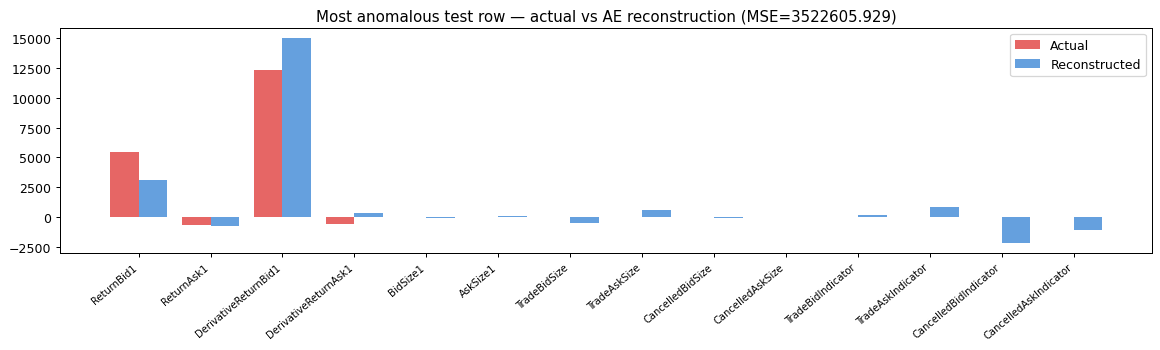

In [9]:
print('Fitting RobustScaler on the normal pool for the autoencoder...')
ae_scaler = RobustScaler()
X_normal_sc = ae_scaler.fit_transform(X_normal)
X_test_ae   = ae_scaler.transform(X_test)
X_val_ae    = ae_scaler.transform(X_val)

print('Training Dense Autoencoder (37 -> 20 -> 8 -> 20 -> 37) on normal data only...')
ae = MLPRegressor(
    hidden_layer_sizes=(20, 8, 20),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=50,
    batch_size=1024,
    random_state=42,
    verbose=False,
)
ae.fit(X_normal_sc, X_normal_sc)
print(f'Done. Final training loss: {ae.loss_:.6f}')

# Reconstruction error on test = anomaly score
X_test_recon = ae.predict(X_test_ae)
recon_err_test = np.mean((X_test_ae - X_test_recon)**2, axis=1)
ae_test = minmax_01(recon_err_test)

X_val_recon = ae.predict(X_val_ae)
recon_err_val = np.mean((X_val_ae - X_val_recon)**2, axis=1)
ae_val = minmax_01(recon_err_val)

print(f'\nAE test score (normalized reconstruction error):')
print(f'  raw MSE range: [{recon_err_test.min():.4f}, {recon_err_test.max():.4f}]')
print(f'  > 0.5 : {(ae_test > 0.5).sum():,} rows')
print(f'  > 0.9 : {(ae_test > 0.9).sum():,} rows')

# Most-anomalous test row's actual vs reconstructed (matches v2's diagnostic plot)
worst_idx = int(np.argmax(recon_err_test))
fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(NUMERIC_FEATURES))
ax.bar(x - 0.2, X_test_ae[worst_idx, :len(NUMERIC_FEATURES)], width=0.4,
       label='Actual', color='#E24B4A', alpha=0.85)
ax.bar(x + 0.2, X_test_recon[worst_idx, :len(NUMERIC_FEATURES)], width=0.4,
       label='Reconstructed', color='#4A90D9', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(NUMERIC_FEATURES, rotation=40, ha='right', fontsize=8)
ax.set_title(f'Most anomalous test row — actual vs AE reconstruction (MSE={recon_err_test[worst_idx]:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Ensemble — RF + SVM + Autoencoder

The three components have **complementary blind spots**:

| Model | What it captures | What it misses |
|---|---|---|
| RF | non-linear *interactions* (e.g. `burst_size × max_zscore`) of synthetic-anomaly type | anomalies the synthetic injection didn't simulate |
| SVM | the *linear separator* in synthetic-anomaly space | non-linear interactions; non-injected anomaly types |
| AE | rows that don't reconstruct under the learned normal manifold | individual mass-spike features (still in the "normal" reconstruction set) |

We combine via **equal-weighted average** of the three normalized `[0,1]` scores, then re-min-max the result. Equal weights are a reasonable default given we have no labelled validation set to tune them on; the v2 final model uses 25/25/50 (AE/IF/zscore) weights based on Kaggle leaderboard feedback. We could tune these later once we have leaderboard signal.

Ensemble test score statistics:
  range : [0.0000, 1.0000]
  > 0.5 : 22 rows
  > 0.9 : 3 rows


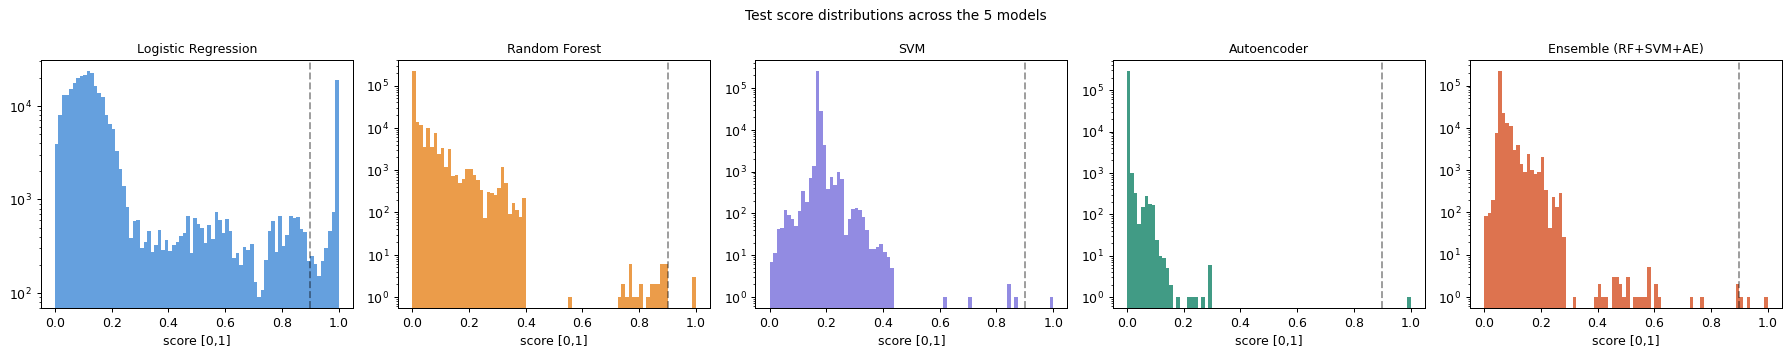


Saved submission to: submission_simple_models.csv
  rows : 289,101
  > 0.9: 3 flagged rows
   ID  TARGET
0   0  0.0972
1   1  0.0571
2   2  0.0532
3   3  0.0584
4   4  0.0532


In [10]:
ensemble_test = minmax_01((rf_test + svm_test + ae_test) / 3.0)
ensemble_val  = minmax_01((rf_val  + svm_val  + ae_val ) / 3.0)

print(f'Ensemble test score statistics:')
print(f'  range : [{ensemble_test.min():.4f}, {ensemble_test.max():.4f}]')
print(f'  > 0.5 : {(ensemble_test > 0.5).sum():,} rows')
print(f'  > 0.9 : {(ensemble_test > 0.9).sum():,} rows')

# Compare all five score distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, score, label, color in zip(
    axes,
    [lr_test, rf_test, svm_test, ae_test, ensemble_test],
    ['Logistic Regression', 'Random Forest', 'SVM', 'Autoencoder', 'Ensemble (RF+SVM+AE)'],
    ['#4A90D9', '#E88B2A', '#7F77DD', '#1F8A70', '#D85A30'],
):
    ax.hist(score, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_yscale('log')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('score [0,1]')
    ax.axvline(0.9, color='black', linestyle='--', alpha=0.4)
plt.suptitle('Test score distributions across the 5 models', fontsize=11)
plt.tight_layout()
plt.show()

# Save the ensemble submission
sub = pd.DataFrame({'ID': test['ID'].values, 'TARGET': ensemble_test})
sub_path = 'submission_simple_models.csv'
sub.to_csv(sub_path, index=False)
print(f'\nSaved submission to: {sub_path}')
print(f'  rows : {len(sub):,}')
print(f'  > 0.9: {(sub["TARGET"] > 0.9).sum():,} flagged rows')
print(sub.head())

## 9. Synthetic-AUROC Validation

Test labels are hidden, so we estimate AUROC with the same trick `validate_auroc.py` uses: inject a **fresh** batch of synthetic anomalies into val (using a different seed than Section 3 so the supervised models haven't seen these specific perturbations), score the combined "real-normal val + synthetic-fraud" set with each model, and compute AUROC against the known labels.

This is a **lower bound**: real anomalies in test may be more or less separable than synthetic ones. The numbers below are useful for ranking the 5 models against each other; the actual leaderboard score may differ.

Building evaluation set: 467,939 normal val rows + 5,000 fresh synthetic anomalies...



=== Synthetic AUROC by model (val normals + 5,000 fresh synthetic anomalies) ===
  Logistic Regression        AUROC = 0.9543
  Random Forest              AUROC = 1.0000
  SVM (linear)               AUROC = 0.9643
  Autoencoder                AUROC = 0.9966
  Ensemble (RF+SVM+AE)       AUROC = 1.0000


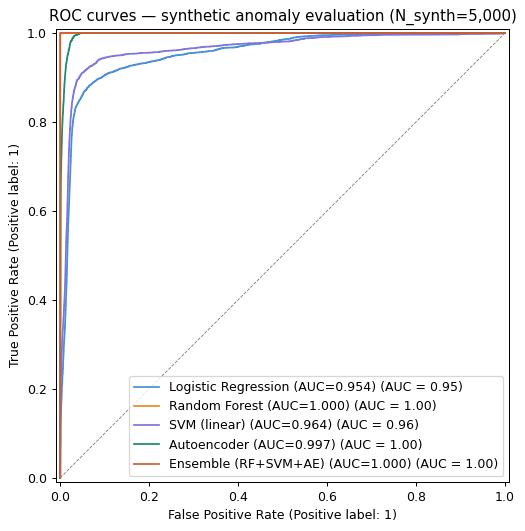

In [11]:
N_EVAL_SYNTH = 5_000

# Build evaluation set: all of val (label=0) + N_EVAL_SYNTH synthetic anomalies (label=1).
# Use a NEW seed so these perturbations are not the ones the supervised models trained on.
print(f'Building evaluation set: {len(val):,} normal val rows + {N_EVAL_SYNTH:,} fresh synthetic anomalies...')
eval_synth = inject_synthetic_anomalies(val, N_EVAL_SYNTH, seed=99)
eval_df    = pd.concat([val, eval_synth], ignore_index=True)
eval_df, X_eval = engineer_features(eval_df, stats)
y_eval = np.array([0]*len(val) + [1]*N_EVAL_SYNTH)
X_eval_sup = sup_scaler.transform(X_eval)
X_eval_ae  = ae_scaler .transform(X_eval)

# Score with each model
lr_eval  = lr.predict_proba(X_eval_sup)[:, 1]
rf_eval  = rf.predict_proba(X_eval)[:, 1]
svm_eval = minmax_01(svm.decision_function(X_eval_sup))
recon_e  = np.mean((X_eval_ae - ae.predict(X_eval_ae))**2, axis=1)
ae_eval  = minmax_01(recon_e)
ens_eval = minmax_01((rf_eval + svm_eval + ae_eval) / 3.0)

# Compute synthetic AUROC for each
results = {
    'Logistic Regression':    roc_auc_score(y_eval, lr_eval),
    'Random Forest':          roc_auc_score(y_eval, rf_eval),
    'SVM (linear)':           roc_auc_score(y_eval, svm_eval),
    'Autoencoder':            roc_auc_score(y_eval, ae_eval),
    'Ensemble (RF+SVM+AE)':   roc_auc_score(y_eval, ens_eval),
}

print(f'\n=== Synthetic AUROC by model (val normals + {N_EVAL_SYNTH:,} fresh synthetic anomalies) ===')
for name, auc in results.items():
    print(f'  {name:25s}  AUROC = {auc:.4f}')

# ROC curve plot
fig, ax = plt.subplots(figsize=(7, 6))
for name, score, color in zip(
    results.keys(),
    [lr_eval, rf_eval, svm_eval, ae_eval, ens_eval],
    ['#4A90D9','#E88B2A','#7F77DD','#1F8A70','#D85A30']
):
    RocCurveDisplay.from_predictions(y_eval, score, ax=ax,
                                      name=f'{name} (AUC={results[name]:.3f})',
                                      color=color, linewidth=1.4)
ax.plot([0,1],[0,1],'--',color='gray',linewidth=0.7)
ax.set_title(f'ROC curves — synthetic anomaly evaluation (N_synth={N_EVAL_SYNTH:,})')
plt.tight_layout()
plt.show()

## 10. Save Per-Model Submissions to `submissions/`

Each of the 5 models produces a per-row anomaly score on test. We save each one as its own Kaggle-format submission CSV (columns: `ID`, `TARGET`) in a dedicated `submissions/` folder, so they can be uploaded individually to compare leaderboard scores.

In [12]:
import os
os.makedirs('submissions', exist_ok=True)

per_model_subs = {
    'submission_logistic_regression.csv': lr_test,
    'submission_random_forest.csv':       rf_test,
    'submission_svm.csv':                  svm_test,
    'submission_autoencoder.csv':          ae_test,
    'submission_ensemble.csv':             ensemble_test,
}

print(f'Saving {len(per_model_subs)} per-model submissions to ./submissions/')
print(f'  test rows: {len(test):,}')
print()
print(f'  {"file":42s}  {"min":>8s}  {"max":>8s}  {">0.5":>8s}  {">0.9":>8s}')
for fname, scores in per_model_subs.items():
    sub  = pd.DataFrame({'ID': test['ID'].values, 'TARGET': scores})
    path = os.path.join('submissions', fname)
    sub.to_csv(path, index=False)
    n_50 = (scores > 0.5).sum()
    n_90 = (scores > 0.9).sum()
    print(f'  {fname:42s}  {scores.min():>8.4f}  {scores.max():>8.4f}  {n_50:>8,}  {n_90:>8,}')

print('\nFiles in submissions/:')
for f in sorted(os.listdir('submissions')):
    size_kb = os.path.getsize(os.path.join('submissions', f)) / 1024
    print(f'  {f:42s}  {size_kb:>7.1f} KB')

Saving 5 per-model submissions to ./submissions/
  test rows: 289,101

  file                                             min       max      >0.5      >0.9


  submission_logistic_regression.csv            0.0000    1.0000    34,164    21,005


  submission_random_forest.csv                  0.0000    1.0000        37         3


  submission_svm.csv                            0.0000    1.0000         6         1


  submission_autoencoder.csv                    0.0000    1.0000         1         1


  submission_ensemble.csv                       0.0000    1.0000        22         3

Files in submissions/:
  submission_autoencoder.csv                   8458.7 KB
  submission_ensemble.csv                      7835.2 KB
  submission_logistic_regression.csv           7684.5 KB
  submission_random_forest.csv                 4622.4 KB
  submission_svm.csv                           7710.0 KB
